<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801SL_Assignment2_Q2_1_Philine_Potgieter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Improrting Libraries



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from IPython.display import Markdown, display

In [2]:
mode1 = pd.read_excel('/content/sample_data/mode1.xlsx')

In [3]:
mode1.head()

,X
0,95.795
1,235.536
2,125.419
3,194.497
4,124.638


In [4]:
mode1.count()

,0
X,1500


##Question 1 a) Histogram

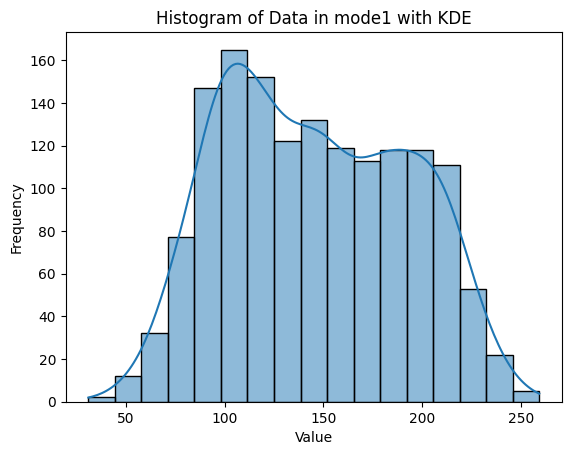

In [5]:
sns.histplot(data=mode1, x='X', kde=True)
plt.title('Histogram of Data in mode1 with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

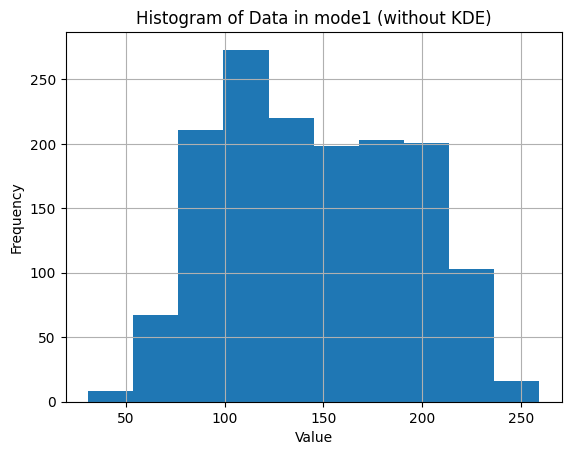

In [6]:
mode1.hist()
plt.title('Histogram of Data in mode1 (without KDE)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

##Question 1 b) Gaussian Mixture model with nr of cluster scenarios to find the best model

In [7]:
X = mode1['X'].values.reshape(-1, 1)

n_components_list = [2, 5, 10, 15, 20, 30, 40]

results = []

for n_components in n_components_list:
    start_time = time.time()

    gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
    gmm.fit(X)

    end_time = time.time()
    runtime = end_time - start_time


    aic = gmm.aic(X)
    bic = gmm.bic(X)

    results.append({
        'n_components': n_components,
        'Runtime (s)': runtime,
        'AIC': aic,
        'BIC': bic
    })


results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

|   n_components |   Runtime (s) |     AIC |     BIC |
|---------------:|--------------:|--------:|--------:|
|              2 |      0.112146 | 15584.1 | 15610.7 |
|              5 |      0.16077  | 15581.7 | 15656   |
|             10 |      0.214309 | 15600.1 | 15754.2 |
|             15 |      0.269667 | 15615.7 | 15849.5 |
|             20 |      0.353291 | 15627.7 | 15941.2 |
|             30 |      0.509598 | 15669.5 | 16142.3 |
|             40 |      0.67944  | 15702.3 | 16334.6 |


## Question 2 c) Best model & cluster characteristics

In [8]:
optimal_n_components = 2

gmm_optimal = GaussianMixture(n_components=optimal_n_components, random_state=42, n_init=10)
gmm_optimal.fit(X)

# Model Parameters
print("\ Model Parameters:")
print(f"  Component Weights (Proportions): {gmm_optimal.weights_}")
print(f"  Component Means: {gmm_optimal.means_.flatten()}")
print(f"  Component Covariances (Variances for 1D data): {gmm_optimal.covariances_.flatten()}")

# Cluster Assignments
print("\ Cluster Assignments:")
cluster_labels = gmm_optimal.predict(X)

cluster_counts = []
for i in range(gmm_optimal.n_components):
    count = np.sum(cluster_labels == i)
    cluster_counts.append({'Cluster': i, 'Count': count})
    print(f"  Cluster {i}: {count} data points")

\ Model Parameters:
  Component Weights (Proportions): [0.4521585 0.5478415]
  Component Means: [187.56406607 110.82164826]
  Component Covariances (Variances for 1D data): [716.35426096 654.00668268]
\ Cluster Assignments:
  Cluster 0: 677 data points
  Cluster 1: 823 data points


<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_5915/3762639922.py:7: SyntaxWarning: invalid escape sequence '\ '
  print("\ Model Parameters:")
/tmp/ipykernel_5915/3762639922.py:13: SyntaxWarning: invalid escape sequence '\ '
  print("\ Cluster Assignments:")


In [9]:
cluster_comparison_data = []

for i in range(optimal_n_components):
    cluster_comparison_data.append({
        'Cluster': i,
        'Data Points': cluster_counts[i]['Count'],
        'Weight': gmm_optimal.weights_[i],
        'Mean': gmm_optimal.means_.flatten()[i],
        'Covariance (Variance)': gmm_optimal.covariances_.flatten()[i]
    })

comparison_df = pd.DataFrame(cluster_comparison_data)

display(Markdown(f"**--- Cluster Characteristics Comparison Table ({optimal_n_components}-Components GMM) ---**"))
display(Markdown(comparison_df.to_markdown(index=False)))

**--- Cluster Characteristics Comparison Table (2-Components GMM) ---**

|   Cluster |   Data Points |   Weight |    Mean |   Covariance (Variance) |
|----------:|--------------:|---------:|--------:|------------------------:|
|         0 |           677 | 0.452158 | 187.564 |                 716.354 |
|         1 |           823 | 0.547842 | 110.822 |                 654.007 |

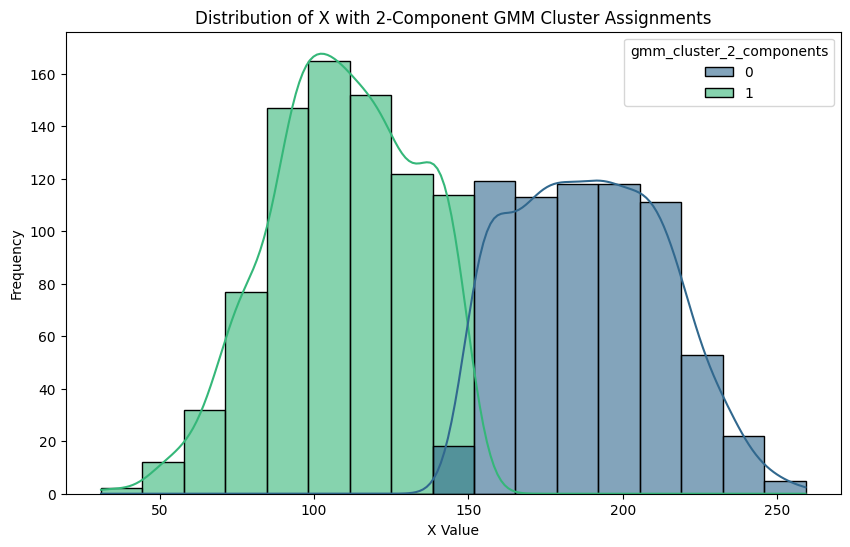

In [10]:
plt.figure(figsize=(10, 6))
mode1[f'gmm_cluster_{optimal_n_components}_components'] = cluster_labels
sns.histplot(data=mode1, x='X', hue=f'gmm_cluster_{optimal_n_components}_components', kde=True, palette='viridis', alpha=0.6)
plt.title(f'Distribution of X with {optimal_n_components}-Component GMM Cluster Assignments')
plt.xlabel('X Value')
plt.ylabel('Frequency')
plt.show()

In [11]:
posterior_probabilities = gmm_optimal.predict_proba(X)

overlap_max_prob_threshold = 0.7

max_posterior_probs = np.max(posterior_probabilities, axis=1)
num_overlapping_points = np.sum(max_posterior_probs < overlap_max_prob_threshold)
percentage_overlapping = (num_overlapping_points / len(X)) * 100

for i in range(gmm_optimal.n_components):
    mode1[f'p_cluster_{i}'] = posterior_probabilities[:, i]

In [12]:
optimal_results = results_df[results_df['n_components'] == optimal_n_components]
aic_optimal = optimal_results['AIC'].values[0]
bic_optimal = optimal_results['BIC'].values[0]

print(f"\n--- AIC for the {optimal_n_components}-Component GMM: {aic_optimal:.2f} ---")
print(f"--- BIC for the {optimal_n_components}-Component GMM: {bic_optimal:.2f} ---")


--- AIC for the 2-Component GMM: 15584.10 ---
--- BIC for the 2-Component GMM: 15610.67 ---


In [13]:
# Calculate and print the log-likelihood for the optimal GMM
log_likelihood = gmm_optimal.score(X) * len(X)
print(f"\n--- Log-Likelihood for {optimal_n_components}-Component GMM: {log_likelihood:.2f} ---")


--- Log-Likelihood for 2-Component GMM: -7787.05 ---


In [14]:
# Calculate and print the predictive likelihood (average log-likelihood per sample)
predictive_likelihood = gmm_optimal.score(X)
print(f"\n--- Predictive Likelihood (Avg. Log-Likelihood per Sample) for {optimal_n_components}-Component GMM: {predictive_likelihood:.2f} ---")


--- Predictive Likelihood (Avg. Log-Likelihood per Sample) for 2-Component GMM: -5.19 ---


In [15]:
# Calculate and print the Silhouette Score for the optimal GMM
silhouette_score_optimal = silhouette_score(X, gmm_optimal.predict(X))
print(f"\n--- Silhouette Score for {optimal_n_components}-Component GMM: {silhouette_score_optimal:.3f} ---")


--- Silhouette Score for 2-Component GMM: 0.623 ---


In [16]:
# Display a sample of the posterior probabilities
print(f"\n--- Sample of Posterior Probabilities for {optimal_n_components}-Component GMM ---")
display(mode1[['X', 'p_cluster_0', 'p_cluster_1']].head())




--- Sample of Posterior Probabilities for 2-Component GMM ---


,X,p_cluster_0,p_cluster_1
0,95.795,0.002617,0.997383
1,235.536,0.999957,0.000043
2,125.419,0.058957,0.941043
3,194.497,0.993830,0.006170
4,124.638,0.054407,0.945593


In [18]:
import numpy as np

def calculate_point_entropy(p0, p1):
    entropy = 0
    if p0 > 0:
        entropy -= p0 * np.log2(p0)
    if p1 > 0:
        entropy -= p1 * np.log2(p1)
    return entropy

if 'p_cluster_0' in mode1.columns and 'p_cluster_1' in mode1.columns:
    mode1['entropy'] = mode1.apply(lambda row: calculate_point_entropy(row['p_cluster_0'], row['p_cluster_1']), axis=1)
    average_entropy = mode1['entropy'].mean()
    print(f"\n--- Average Entropy of Posterior Probabilities for {optimal_n_components}-Component GMM: {average_entropy:.3f} ---")
    print("\n--- Sample of Data with Calculated Entropy ---")
    display(mode1[['X', 'p_cluster_0', 'p_cluster_1', 'entropy']].head())
else:
    print("Error")



--- Average Entropy of Posterior Probabilities for 2-Component GMM: 0.263 ---

--- Sample of Data with Calculated Entropy ---


,X,p_cluster_0,p_cluster_1,entropy
0,95.795,0.002617,0.997383,0.026223
1,235.536,0.999957,0.000043,0.000690
2,125.419,0.058957,0.941043,0.323292
3,194.497,0.993830,0.006170,0.054168
4,124.638,0.054407,0.945593,0.304830
